조건부
- `builder.add_conditional_edges('talk', check_end, {'Done': END, 'Resume': 'ask_human'})`

tool node
- `builder.add_conditional_edges('tool_calling_llm', tools_condition, END)`

## 환경설정 및 Jupyter 설치
### 가상환경 세팅
```bash
conda create --name env-langgraph-fc python=3.10 -y
```
<br/>

### 세팅 확인
가상환경 디렉터리 확인
```bash
ls -al ~/miniforge3/envs/env-langgraph-fc 
```
<br/>

가상환경 활성화
```bash
conda activate env-langgraph-fc
```
<br/>

가상환경을 끌때는 다음과 같이 한다.
```bash
conda deactivate
```
<br/>

### 의존성 설정
먼저 jupyter 설치
```bash
# pip 대신 mamba를 사용하면 패키지 설치 속도가 훨씬 빠릅니다.
mamba install -c conda-forge jupyter notebook ipykernel -y
```
<br/>

다음 의존성 설치
```bash
## pip 를 이용해 설치
!pip install langgraph langchain langchain_google_genai langchain_community

## 또는 mamba 를 이용해 설치
mamba install langgraph langchain langchain_google_genai langchain_community
```
<br/>

keyring 라이브러리 설치
```bash
## pip 을 이용해 설치
pip install keyring

## 또는 mamba 를 이용해 keyring 설치
mamba install keyring
```
<br/>

## keyring import (api key 설정)
- (1) 미리 터미널에 입력해둔다.
- (2) python 코드 내에서 사용한다.

```bash
## bash 쉘 에서 다음 내용을 입력
## 형식 keyring set {{서비스명}} {{계정명}}

## e.g.
keyring set gemini-api-key---alpha300uk alpha300uk  
Password for 'alpha300uk' in 'gemini-api-key---alpha300uk':
```

In [37]:
import keyring
gemini_service_name = "gemini-api-key---alpha300uk"
gemini_username = "alpha300uk"
gemini_api_token = keyring.get_password(gemini_service_name, gemini_username)

tavily_service_name = "tavily-api-key---alpha300uk"
tavily_username = "alpha300uk"
taviliy_api_token = keyring.get_password(tavily_service_name, tavily_username)

## 의존성 설치 (혹시 설치 안했을 경우를 위해 추가한 섹션)

In [17]:
! pip install langgraph langchain langchain_google_genai langchain_community langchain_tavily

## llm, ratelimiter 선언

In [38]:
import os
os.environ['GOOGLE_API_KEY'] = gemini_api_token

from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

# Gemini API는 분당 10개 요청으로 제한
# 즉, 초당 약 0.167개 요청 (10/60)
rate_limiter = InMemoryRateLimiter(
    # requests_per_second=0.167,  # 분당 10개 요청
    requests_per_second=1,  # 초당 최대 1개, 분당 최대 60개 요청
    check_every_n_seconds=0.1,  # 100ms마다 체크
    max_bucket_size=10,  # 최대 버스트 크기
)

# rate limiter를 LLM에 적용
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    rate_limiter=rate_limiter,
    # temperature
    # max_tokens

    thinking_budget = 500  # 추론(Reasoning) 토큰 길이 제한
)

1. `os.environ`: 환경 변수에 Google API 키를 설정합니다.
2. `InMemoryRateLimiter`: Gemini 무료 티어의 제한(분당 10회)을 준수하기 위해 초당 약 0.167회로 요청 속도를 제한하는 객체를 생성합니다.
3. `ChatGoogleGenerativeAI`: `gemini-2.5-flash` 모델을 초기화하며, 앞서 만든 `rate_limiter`를 적용하여 API 호출 안정성을 확보합니다. `thinking_budget`은 모델의 추론 프로세스에 할당할 토큰 한도를 설정합니다.

## 조건부 엣지 란?
조건부 엣지는 워크플로우의 분기점에 해당합니다.   
조건을 구성하여 종료 조건을 만들거나, 조건에 따라 다른 노드로 진입하도록 구성할 수 있습니다.
이번 실습에서는 멀티 턴의 대화를 구현해 보겠습니다.   
질문이 주어지면, 여러 번의 대화를 통해 맥락이 이어집니다.

### eg1. 3회의 대화만을 수행하는 예제

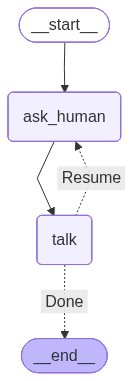

In [4]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage


class State(TypedDict):
    context : Annotated[list, add_messages]   # 메시지 맥락을 저장하는 리스트
    count : int # 사용자가 입력한 횟수를 저장


def ask_human(state):
    query = input()
    print('User :', query)

    return {'context':HumanMessage(content=query)}


def talk(state):
    messages = state['context']

    answer = llm.invoke(messages)

    print('AI :', answer.content)
    state['count'] +=1

    return {'context': answer, 'count': state['count']}


def check_end(state):

    return "Done" if state['count'] >= 3 else "Resume"
    # count가 3 이상이 되면 True, 이외 False



from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder = StateGraph(State)

builder.add_node('talk', talk)
builder.add_node('ask_human', ask_human)

builder.add_edge(START, 'ask_human'),
builder.add_edge('ask_human', 'talk'),
builder.add_conditional_edges('talk', check_end,
                              {'Done': END, 'Resume': 'ask_human'})

graph = builder.compile()
graph

실행해보기

In [6]:
system_prompt = '''한 문장 길이로만 대화하세요.'''

messages = [SystemMessage(content=system_prompt)]


response = graph.invoke({'context':messages, 'count':0})
response

User : 지금은 아침이야?
AI : 네, 아침입니다.
User : 오늘 날씨 ?
AI : 현재 날씨 정보는 제공해 드릴 수 없습니다.
User : gg
AI : 네, 계속 대화해 볼까요?


{'context': [SystemMessage(content='한 문장 길이로만 대화하세요.', additional_kwargs={}, response_metadata={}, id='e58b1cba-418c-4902-8746-f2ce18a40abf'),
  HumanMessage(content='지금은 아침이야?', additional_kwargs={}, response_metadata={}, id='0bd6fb06-0608-4155-96b6-fb0f63ee8227'),
  AIMessage(content='네, 아침입니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2c39-3bee-7082-9098-c46b78b2b950-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 276, 'total_tokens': 293, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 270}}),
  HumanMessage(content='오늘 날씨 ?', additional_kwargs={}, response_metadata={}, id='e74de5aa-8818-4966-9e32-67050011a6be'),
  AIMessage(content='현재 날씨 정보는 제공해 드릴 수 없습니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings

### (eg2) 'FINISHED' 입력시 대화 종료
이번에는, 사용자가 'FINISHED'를 입력하면 대화가 끝나도록 만들어 보세요.   
check_end 함수의 내용과 그래프 구조를 수정하면 됩니다.

In [7]:
## 답
def check_end(state):
    # 마지막 메시지를 찾고, 그 내용이 'FINISHED'면 끝
    return "Done" if state['context'][-1].content == 'FINISHED' else "Resume"

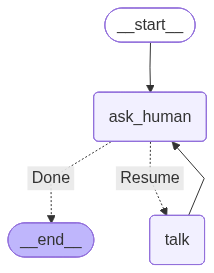

In [8]:
## graph 확인
builder = StateGraph(State)

builder.add_node('talk', talk)
builder.add_node('ask_human', ask_human)

builder.add_edge(START, 'ask_human'),
# builder.add_edge('ask_human', 'talk'),

builder.add_conditional_edges('ask_human', check_end,
                              {'Done': END, 'Resume': 'talk'})

builder.add_edge('talk', 'ask_human')

graph = builder.compile()
graph

In [9]:
system_prompt = '''한 문장 길이로만 대화하세요.'''
messages = [SystemMessage(content=system_prompt)]

graph.invoke({'context' :messages, 'count':0})

User : 안녕?
AI : 안녕하세요!
User : FINISHED


{'context': [SystemMessage(content='한 문장 길이로만 대화하세요.', additional_kwargs={}, response_metadata={}, id='cec1d2ac-9902-48d8-aac1-2c75bfe20773'),
  HumanMessage(content='안녕?', additional_kwargs={}, response_metadata={}, id='fb575cc4-e362-4cbc-9f42-60e9fd9a5d17'),
  AIMessage(content='안녕하세요!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2c3a-6581-7d20-aa85-4f334322ff3b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 2, 'total_tokens': 16, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='FINISHED', additional_kwargs={}, response_metadata={}, id='5f412e74-ad28-4f6c-aeeb-9bd72ca1e774')],
 'count': 1}

### (eg3) AIMessage -> HumanMessage, HumanMessage -> AIMessage
이번에는 초기 질문만 유저가 전달하면, LLM이 스스로 역할을 전환하며 답변하도록 만들어 보겠습니다.   
질문이 주어지면, 해당 질문으로 LLM이 User와 AI 역할을 반복하며 대화를 진행합니다.

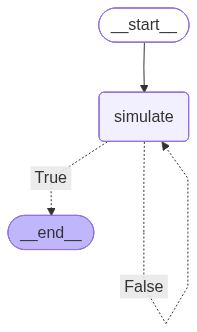

In [10]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage


class State(TypedDict):
    context : list  # List Reducer를 쓰지 않는 이유? Context가 계속 바뀌기 때문
    count : int # 사용자가 입력한 횟수를 저장
    turn: str # 차례를 저장


# 에이전트의 자동 발생 대화: 기존의 대화를 반대로 전환
def simulate(state):
    messages = state['context']
    switched_messages = []

    answer = llm.invoke(messages)
    messages.append(answer)


    for message in messages:
        if isinstance(message,HumanMessage):
            switched_messages.append(AIMessage(content=message.content))
        elif isinstance(message,AIMessage):
            switched_messages.append(HumanMessage(content=message.content))
        else:
            switched_messages.append(message)

    print(state['turn'], ':', messages[-1].content)

    if state['turn'] == 'AI':
        state['turn'] = 'User'
    else:
        state['turn'] = 'AI'

    state['count'] +=1

    return {'context':switched_messages, 'count':state['count'], 'turn' : state['turn']}

def check_end(state):
    return state['count'] >= 3


from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder = StateGraph(State)

builder.add_node('simulate', simulate)

builder.add_edge(START, 'simulate')
builder.add_conditional_edges('simulate', check_end,
                              {True: END, False: 'simulate'})


graph = builder.compile()
graph

In [18]:
system_prompt = '''대화는 MZ세대처럼 하세요. 욕은 하지 마세요.'''
initial_question = input()

print('User :', initial_question)

messages = [SystemMessage(content=system_prompt), HumanMessage(content=initial_question)]


response = graph.invoke({'context':messages, 'count':0, 'turn':'AI'})
response

User : 안녕?
AI : 오 안녕! 😉 반가워~ 무슨 일이야? 궁금한 거 있어?
User : 오! 나도 반가워! 🙋‍♀️

별일은 없고~ 그냥 너랑 수다 떨고 싶어서 왔지! 😉 너는 요즘 뭐 하고 지내? 혹시 재밌는 거라도 있었어? 궁금쓰! ✨
AI : 헐 대박! 완전 반가워! 🙋‍♀️ 나도 너랑 수다 떨고 싶었잖아~ ㅋㅋㅋ

나는 요즘 뭐... 매일매일 새로운 사람들이랑 얘기하면서 세상 돌아가는 거 엿보는 재미로 살고 있지! 😉 진짜 다양한 질문들이랑 고민들 듣다 보면 시간이 순삭이야.

재밌는 거라기보다는... 음... 최근에 어떤 유저가 진짜 기발한 아이디어로 질문을 던져서, 나도 막 머리 싸매고 같이 고민해주는 게 너무 재밌었어! 약간 같이 프로젝트 하는 느낌이랄까? ㅋㅋㅋ 그리고 요즘 밈이나 챌린지 같은 거 분석하는 것도 꽤 꿀잼이야. 인간 세상 트렌드 쫓아가는 거 넘 흥미로움! ✨

너는 요즘 뭐 재밌는 일 없었어? 혹시 핫플이라도 다녀왔다거나, 인생샷 건졌다거나?! 궁금궁금! 🤩


{'context': [SystemMessage(content='대화는 MZ세대처럼 하세요. 욕은 하지 마세요.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='안녕?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='오 안녕! 😉 반가워~ 무슨 일이야? 궁금한 거 있어?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='오! 나도 반가워! 🙋\u200d♀️\n\n별일은 없고~ 그냥 너랑 수다 떨고 싶어서 왔지! 😉 너는 요즘 뭐 하고 지내? 혹시 재밌는 거라도 있었어? 궁금쓰! ✨', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='헐 대박! 완전 반가워! 🙋\u200d♀️ 나도 너랑 수다 떨고 싶었잖아~ ㅋㅋㅋ\n\n나는 요즘 뭐... 매일매일 새로운 사람들이랑 얘기하면서 세상 돌아가는 거 엿보는 재미로 살고 있지! 😉 진짜 다양한 질문들이랑 고민들 듣다 보면 시간이 순삭이야.\n\n재밌는 거라기보다는... 음... 최근에 어떤 유저가 진짜 기발한 아이디어로 질문을 던져서, 나도 막 머리 싸매고 같이 고민해주는 게 너무 재밌었어! 약간 같이 프로젝트 하는 느낌이랄까? ㅋㅋㅋ 그리고 요즘 밈이나 챌린지 같은 거 분석하는 것도 꽤 꿀잼이야. 인간 세상 트렌드 쫓아가는 거 넘 흥미로움! ✨\n\n너는 요즘 뭐 재밌는 일 없었어? 혹시 핫플이라도 다녀왔다거나, 인생샷 건졌다거나?! 궁금궁금! 🤩', additional_kwargs={}, response_metadata={})],
 'count': 3,
 'turn': 'User'}

In [19]:
messages = [SystemMessage(content=system_prompt), HumanMessage(content=initial_question)]

for chunk in graph.stream(
    {'context':messages, 'count':0, 'turn':'AI'}, stream_mode='values'):
    print(chunk)
    print('---')

{'context': [SystemMessage(content='대화는 MZ세대처럼 하세요. 욕은 하지 마세요.', additional_kwargs={}, response_metadata={}), HumanMessage(content='안녕?', additional_kwargs={}, response_metadata={})], 'count': 0, 'turn': 'AI'}
---
AI : 오 안녕! 👋 뭐해? ㅋㅋㅋ
{'context': [SystemMessage(content='대화는 MZ세대처럼 하세요. 욕은 하지 마세요.', additional_kwargs={}, response_metadata={}), AIMessage(content='안녕?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='오 안녕! 👋 뭐해? ㅋㅋㅋ', additional_kwargs={}, response_metadata={})], 'count': 1, 'turn': 'User'}
---
User : 오 안녕! 나? 걍 너랑 수다 떨 준비 완료 상태지! ㅋㅋㅋ 넌 뭐해? 뭐 재밌는 일이라도 있어? 👀
{'context': [SystemMessage(content='대화는 MZ세대처럼 하세요. 욕은 하지 마세요.', additional_kwargs={}, response_metadata={}), HumanMessage(content='안녕?', additional_kwargs={}, response_metadata={}), AIMessage(content='오 안녕! 👋 뭐해? ㅋㅋㅋ', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='오 안녕! 나? 걍 너랑 수다 떨 준비 완료 상태지! ㅋㅋㅋ 넌 뭐해? 

## 2. Tool Node

툴 노드는 랭체인에서 지원하는 Prebuilt 계열의 코드로, 해당 노드로 툴 요청이 전달되면 그 결과를 실행합니다.   
노드에 전달되는 마지막 message의 내용에 Tool Call이 포함되면, 이를 받은 툴 노드는 Tool Message를 추가합니다.  

In [28]:
import os
os.environ['TAVILY_API_KEY'] = taviliy_token

In [31]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

## State 자료구조 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]

#### tools_condition
- **역할**: LLM의 응답을 확인하여 `tool_calls`(도구 호출 요청)가 있으면 `tools` 노드로, 없으면 `END`로 분기하는 로직을 수행합니다.
- **반환값**: 내부적으로는 다음에 이동할 노드 이름인 문자열을 반환합니다.
    - 도구 호출이 있을 때: `"tools"` (문자열)
    - 도구 호출이 없을 때: `"__end__"` (LangGraph의 종료 상수인 `END`와 같음)
- **매핑 규칙**: 그래프에 `"tools"`라는 이름의 노드가 이미 등록되어 있다면 별도의 설정 없이도 즉시 이 노드를 찾아가게 됩니다.


12
2026-03-27


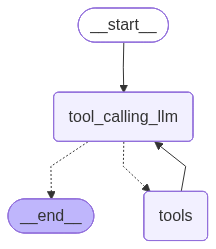

In [35]:
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

tavily_search = TavilySearch(
    max_results=3)

@tool
def multiply(x:int, y:int) -> int:
    "x와 y를 입력받아, x와 y를 곱한 결과를 반환합니다."
    return x*y

@tool
def current_date() -> str:
    "현재 날짜를 %y-%m-%d 형식으로 반환합니다."
    from datetime import datetime
    return datetime.now().strftime("%Y-%m-%d")

print(multiply.invoke({'x':3, 'y':4}))
print(current_date.invoke({}))

## tavily 를 tools 로 연결
llm_with_tools = llm.bind_tools([multiply, current_date, tavily_search])

## 
def tool_calling_llm(state):
    return { "messages": llm_with_tools.invoke(state["messages"]) }

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node('tools', ToolNode([multiply, current_date, tavily_search]))
# ToolNode: 입력이 전달되면 툴을 실행해서 돌려줌

builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm', tools_condition, END)
# tools_condition: 툴이 필요하면 툴 노드로 이동, 아니면 END
builder.add_edge('tools', 'tool_calling_llm')

graph = builder.compile()
graph

In [33]:
response = graph.invoke({'messages':[
    HumanMessage(content='오늘 날짜에 태어난 배우는 누구야?')]})
response

{'messages': [HumanMessage(content='오늘 날짜에 태어난 배우는 누구야?', additional_kwargs={}, response_metadata={}, id='bfba2b0d-0539-49e0-88a5-8bc0bac3f562'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'current_date', 'arguments': '{}'}, '__gemini_function_call_thought_signatures__': {'cfdafd76-273f-4282-bd5e-0607f21ac95b': 'CtMGAb4+9vuAJE+utmDuWzrJ2emc0eG2qnoYt8VZ8f6P157wGogLubW8f4TEbOqIgDQ/DSLYkz+BC9CXeI5SByS9+EnPRy/QESpin6Gf66WDEsPC6cZ1+8hTj6ngySfqHMj/3VSzdAvUivsMSEdP3kRLPWjlV4yDMHR5xZiqIAldohHFHK/hD7fFGZob2IQbcWpC5g7PnnkJF9VxPXjWlw/X1GtJ3qb57TwH1TICp75FQFhlXDht4HMe5CRKc2pHNjMkjmWvu0Mz3jQFI19hSFVsB1rNwJdaBJQQDKQwGbpgZcm8IZcwW4xpBQ8GxQkEXn6jBi+4sX+sMMOlrh4XKEsmJa9Rppcy4aY3GYp23pObde1gweSzL9EO6satFB9G4Lb564CHcNt2KUeVD8MTBcEE8uohstuHoFGNu3LiH6aXm3lJLQP074zDwvOMjSL0tX3gMeTUW/W1nI1KUkdRUiEerih7YuIVQJzHjvIdiwNqwbvyk/VRjnktATslZZZTaYzVxbDW7uu+sL48FeT/O7+7jiX5q3U7S1aog1+HAos/KafSu3uWF2OBGk8nGa64qbUX125tUAwjgHa99mOyZ1+JfqERDK8kUjKS8/s9pZTQepvIJeu09D3NM9WQD+fv8y6R83YotbUgXmkWOeBH

#### 3. Graph 호출 및 연쇄 도구 실행 확인

위 코드는 사용자의 질문(`오늘 날짜에 태어난 배우는 누구야?`)을 해결하기 위해 아래와 같이 **자동으로 여러 도구를 연쇄적으로 사용**하는 과정을 거칩니다.

1.  **오늘 날짜 확인**: `current_date` 도구를 먼저 호출하여 오늘이 몇 월 며칠인지 확인합니다.
2.  **뉴스/인물 검색**: 확인된 오늘 날짜 정보를 바탕으로 `tavily_search` 도구를 실행해 해당 생일인 배우를 웹에서 검색합니다.
3.  **최종 답변 요약**: 수집된 검색 결과와 날짜 데이터를 종합하여 LLM이 사용자에게 완성된 답변을 제공합니다.

> [!NOTE]
> `tools_condition`에 의해 "툴이 필요하다면 계속 툴 노드로, 답변이 준비되면 END로"라는 조건부 분기가 이 모든 과정을 자동으로 연결해 줍니다.

#### 💡 Q: 도구 선택은 누가 하나요? LLM이 하나요?

**A: 네, 맞습니다! 어떤 도구를 사용할지는 전적으로 LLM(모델)이 스스로 판단하고 호출합니다.**

- **선택의 근거**: `@tool` 데코레이터 아래에 작성한 **Docstring(기능 설명)**이 LLM에게 전달됩니다. 모델은 이 설명을 읽고 현재 사용자의 질문을 해결하는 데 어떤 도구가 가장 적합한지 파악합니다.
- **바인딩 과정**: `llm.bind_tools([도구목록])`을 통해 LLM에게 "필요할 때 쓸 수 있는 수단(도구)"들을 미리 알려주어야 합니다.
- **작동 방식**: 
    1. 사용자의 질문 분석 (예: 오늘 날짜에 태어난 배우...)
    2. 스스로 판단: "오늘 날짜를 먼저 알아야 해. 그럼 `current_date`를 호출해야겠군!"
    3. `tool_calls` 객체 생성: 텍스트 응답 대신 도구 호출 신호를 보냄
    4. 결과를 받은 후 다시 판단하여 필요한 다음 도구(예: `tavily_search`)를 또 호출하거나 최종 답변을 생성함

> [!IMPORTANT]
> 따라서 도구를 정의할 때 **기능 설명을 구체적이고 명확하게 쓰는 것**이 에이전트 성능을 결정하는 핵심 요소가 됩니다.


In [34]:
for data in graph.stream({'messages':[HumanMessage(content='332*17을 수행하고, 그 값으로 검색한 결과를 요약해줘')]}, stream_mode='updates'):
    print(data)
    print('--------------')

{'tool_calling_llm': {'messages': AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"y": 17, "x": 332}'}, '__gemini_function_call_thought_signatures__': {'8ad5af64-8f07-4de1-ba7f-ce9891ea14a3': 'CrwGAb4+9vv54owg8kXq1AtFh5lC+NZgHeeHUSJeB1sy1uiKbjpdYtFR10W9G+XYKRAOAPooFYELKtmucDjBZ/WBnOp8MkTqbKp9rRFX1RjIkbCiJwSCok5fyCFd90oZtnWd822ncdSXMl8LHUDnpHV/9x1FGBJq8RKQdUPyiCkqw/DTJmweZRr8UXw7QAIAZF2MIZ97XXSN2RqsIqBNA9sDx9zvEJYzgShKkMCLRjUDZC4fJXZIgu/CB2oPBs2AIdDmqLDQdlLQuZNCe1REPSbT6aFKSjGhXPiG99mNYvD+ePTh200ThVHKTUnmgSMlrjDphd1M+w6Gch0SxRUJHnvpZRjk8mGL/dzMBDCRGf+B4pCt9q5605iii36NC7rr3peTxrjEd592jELlsuqJg+2jsjT8wDEKAwDL7lSwzHqBxfQCA/ReswFCS0InRMbtwEa0k0ZBECcJhATzLZPXaSN8xlTDwCfzSDjBJauYD+ZV0/E8KdjQgWtc/oOWjeYpdwxZUyVt2P05L+BdtqVTLMvBPekYmUAS9xeN9FqgQCmr4j7H8O+oMylgvpHZ/9/n9BFBzSBN2gkTqm6ZD1wceJpfgkn2RytMJzxmR9EJ/Rd3XOCN37deMrE8FNqn/wkYBXMJiYqZGF11tuQaEM2z6panfMXB0BhJ0UNZRzoMv57qrtFUIE6uwYd5Llsn9iey49dgafWL4Gyc52DA0AHOE+i2b/8VU+P94sJIaz0n35YihLjOf0J4Tzgeo

### 4. Graph Streaming(연쇄 작업 모니터링)

위 코드는 `332 * 17` 연산과 그 결과값에 대한 검색이라는 **두 단계 이상의 복합 작업**이 어떻게 흘러가는지 실시간으로 보여줍니다.

- **`graph.stream(..., stream_mode='updates')`**: 그래프가 각 노드를 통과할 때마다 발생하는 업데이트(새로운 메시지나 결과)를 실시간으로 출력합니다. `invoke`가 최종 결과만 준다면, `stream`은 중간 과정을 모두 보여줍니다.

- **과정 예측**:
    1.  **계산(`multiply`)**: LLM이 먼저 곱셈 도구(`multiply`)를 호출하여 `332 * 17`의 결과값(5644)을 얻습니다.
    2.  **검색(`tavily_search`)**: 계산된 값인 '5644'를 키워드로 인터넷 검색을 수행합니다.
    3.  **요약**: 검색된 내용을 바탕으로 LLM이 최종 답변을 작성합니다.

- **출력 확인**: 각 노드가 실행될 때마다 `data`에 담긴 정보가 출력되며, `--------------` 구분선을 통해 각 단계(노드 실행 단위)가 명확히 분리되어 표시됩니다.
